In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import importlib
from tqdm import tqdm

import utils

results_dir = Path() / "results" / "sample_uniformity"
figures_dir = Path() / "figures"

method_to_label = {
    "iarap": "Ours",
    "ling": "Ling et al.",
    "reference": "Reference",
}

In [2]:
cache = True # Set to True to skip already benchmarked configurations
methods = ["iarap", "reference"]
num_rays = [100, 500, 1000, 5000, 10000, 50000, 100000, 1000000, 2000000, 3000000] # For reference, these are the number of *samples*

results_dir.mkdir(parents=True, exist_ok=True)

for method in tqdm(methods):
    for num_ray in tqdm(num_rays, leave=False):
        output_path = results_dir / f"{method}_{num_ray}.csv"
        if output_path.exists() and cache:
            print(f"Skipping {method} with {num_ray} rays (cached).")
            continue
        
        utils.call_script(Path().absolute() / "measure_sample_uniformity.py", method=method, num_rays=num_ray, dataset="neural_iarap", num_runs=1, sdf_filter="bunny", output=results_dir / f"{method}_{num_ray}.csv")

100%|██████████| 2/2 [02:40<00:00, 80.09s/it] 


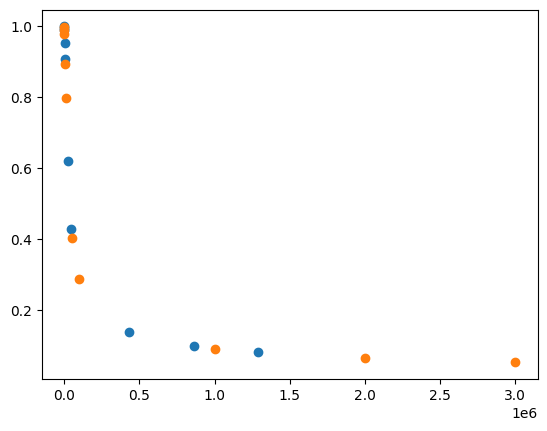

In [4]:
importlib.reload(utils)

# Load and merge all dataframes
dataframes = [pd.read_csv(f) for f in results_dir.glob("*.csv")]
df_raw = pd.concat(dataframes, ignore_index=True)

# Iterate all methods in the dataframe and add scatter plot (num_samples vs total variation)
for method in df_raw["method"].unique():
    df_method = df_raw[df_raw["method"] == method]
    plt.scatter(df_method["num_samples"], df_method["total_variation"], label=method_to_label[method])